# FaceInsight-AI EDA

# Overview
This notebook performs Exploratory Data Analysis (EDA) on the CelebA dataset using KaggleHub. It examines three CSV files extracted from the dataset:
- `list_attr_celeba.csv` â€” facial attribute annotations
- `list_bbox_celeba.csv` â€” bounding box coordinates for face regions
- `list_eval_partition.csv` â€” train/validation/test split indicators

The notebook covers data loading, summary statistics, and visualization of distributions, correlations, and scatter relationships across each dataset.

# Setup
Import required libraries and set up the environment for analysis.

## Environment Setup
Import core libraries for data manipulation, visualization, and numerical computing.


In [138]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

### Data Directory Configuration
Define the dataset root and validate that all required CelebA CSV files are present.


In [139]:
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'archive')
print(f"DATA_DIR: {DATA_DIR}")

# Validate dataset availability
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print(f"CSV files: {csv_files}")
required = [
    'list_attr_celeba.csv',
    'list_bbox_celeba.csv',
    'list_landmarks_align_celeba.csv',
    'list_eval_partition.csv',
]
missing = [f for f in required if f not in csv_files]
if missing:
    raise FileNotFoundError(f"Missing CSV files: {missing}")


DATA_DIR: d:\CODING\project\TODO Projects\FaceInsight-AI\archive
CSV files: ['celeba_merged.csv', 'face_metadata.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv', 'list_eval_partition.csv', 'list_landmarks_align_celeba.csv']


# Utility Functions
Helper functions for visualizing data distributions, correlation matrices, and scatter plots.

### Visualization Helpers
Utility functions for plotting column distributions, correlation heatmaps, and scatter matrices.


In [140]:
"""
Visualization utilities for dataset exploration.
"""

def plotPerColumnDistribution(df, nGraphPerRow, nGraphShown):
    """
    Plot histograms or bar charts for up to `nGraphShown` columns.

    Args:
        df (pd.DataFrame): Input DataFrame.
        nGraphPerRow (int): Number of subplots per row.
        nGraphShown (int): Maximum number of columns to display.
    """
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    if df.shape[1] == 0:
        print('No valid columns to plot')
        return
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int(np.ceil(nCol / nGraphPerRow))
    plt.figure(figsize=(nGraphPerRow * 6, nGraphRow * 4))
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        col = columnNames[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].hist(bins=30)
        else:
            df[col].value_counts().plot(kind='bar')
        plt.title(f'{col} Distribution')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

def plotCorrelationMatrix(df, size):
    """
    Plot a correlation heatmap for numeric columns.

    Args:
        df (pd.DataFrame): Input DataFrame.
        size (int): Figure size in inches (square).
    """
    corr = df.select_dtypes(include=[np.number]).corr()
    if corr.shape[0] < 2:
        print('Not enough numeric columns for correlation matrix')
        return
    plt.figure(figsize=(size, size))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

def plotScatterMatrix(df, plotSize, textSize):
    """
    Plot a scatter matrix for up to 10 numeric columns.

    Args:
        df (pd.DataFrame): Input DataFrame.
        plotSize (int): Figure size in inches (square).
        textSize (int): Unused; retained for API compatibility.
    """
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] < 2:
        print('Not enough numeric columns for scatter matrix')
        return
    if numeric.shape[1] > 10:
        numeric = numeric.iloc[:, :10]
    plt.figure(figsize=(plotSize, plotSize))
    pd.plotting.scatter_matrix(numeric, figsize=(plotSize, plotSize))
    plt.show()


# Data Download
Download the CelebA dataset from Kaggle using `kagglehub`. The dataset is persisted locally and can be reused across notebook sessions.

# Data Dictionary — `list_attr_celeba.csv`

| Column | Type | Description |
|--------|------|-------------|
| `image_id` | string | Filename of the celebrity image |
| `5_o_Clock_Shadow` … `Wearing_Necktie` | int (-1/1) | 40 binary facial attributes; -1 = absent, 1 = present |


# DataFrame 1 â€” Facial Attributes (`list_attr_celeba.csv`)
This dataset contains 40 binary facial attributes (e.g., Smiling, Male, Wearing_Hat) annotated for each celebrity image. We load a sample of 1000 rows and visualize the distributions and correlations.

### Loading Facial Attributes
Read a sample of the CelebA facial attributes CSV to inspect its structure and contents.


In [141]:
nRowsRead = 1000
df1 = pd.read_csv(os.path.join(DATA_DIR, 'list_attr_celeba.csv'), delimiter=',', nrows=nRowsRead)
df1.dataframeName = 'list_attr_celeba.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')
print('\n--- Schema ---')
print(df1.dtypes)
print('\n--- Missing Values ---')
print(df1.isnull().sum())
print('\n--- Unique Values Count ---')
print(df1.nunique())
print('\n--- Head ---')
display(df1.head(3))
print('\n--- Describe ---')
display(df1.describe(include='all'))


There are 1000 rows and 41 columns

--- Schema ---
image_id                 str
5_o_Clock_Shadow       int64
Arched_Eyebrows        int64
Attractive             int64
Bags_Under_Eyes        int64
Bald                   int64
Bangs                  int64
Big_Lips               int64
Big_Nose               int64
Black_Hair             int64
Blond_Hair             int64
Blurry                 int64
Brown_Hair             int64
Bushy_Eyebrows         int64
Chubby                 int64
Double_Chin            int64
Eyeglasses             int64
Goatee                 int64
Gray_Hair              int64
Heavy_Makeup           int64
High_Cheekbones        int64
Male                   int64
Mouth_Slightly_Open    int64
Mustache               int64
Narrow_Eyes            int64
No_Beard               int64
Oval_Face              int64
Pale_Skin              int64
Pointy_Nose            int64
Receding_Hairline      int64
Rosy_Cheeks            int64
Sideburns              int64
Smiling              

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1



--- Describe ---


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
count,1000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
unique,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,000001.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,-0.752000,-0.450000,0.0400,-0.566000,-0.956000,-0.702000,-0.506000,-0.504000,-0.492000,...,-0.886000,0.0200,-0.564000,-0.426000,-0.586000,-0.912000,-0.078000,-0.744000,-0.842000,0.508000
std,NaN,0.659493,0.893475,0.9997,0.824818,0.293513,0.712533,0.862965,0.864136,0.871031,...,0.463917,1.0003,0.826188,0.905176,0.810717,0.410395,0.997452,0.668514,0.539747,0.861788
min,NaN,-1.000000,-1.000000,-1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,NaN,-1.000000,-1.000000,-1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
50%,NaN,-1.000000,-1.000000,1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
75%,NaN,-1.000000,1.000000,1.0000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,-1.000000,1.0000,-1.000000,1.000000,-1.000000,-1.000000,1.000000,-1.000000,-1.000000,1.000000


### Preview of Attribute Data
Display the first five rows of the facial attributes dataset.


In [142]:
df1.head(5)

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


### Attribute Distributions
Visualize the frequency distributions of the 40 binary facial attributes.


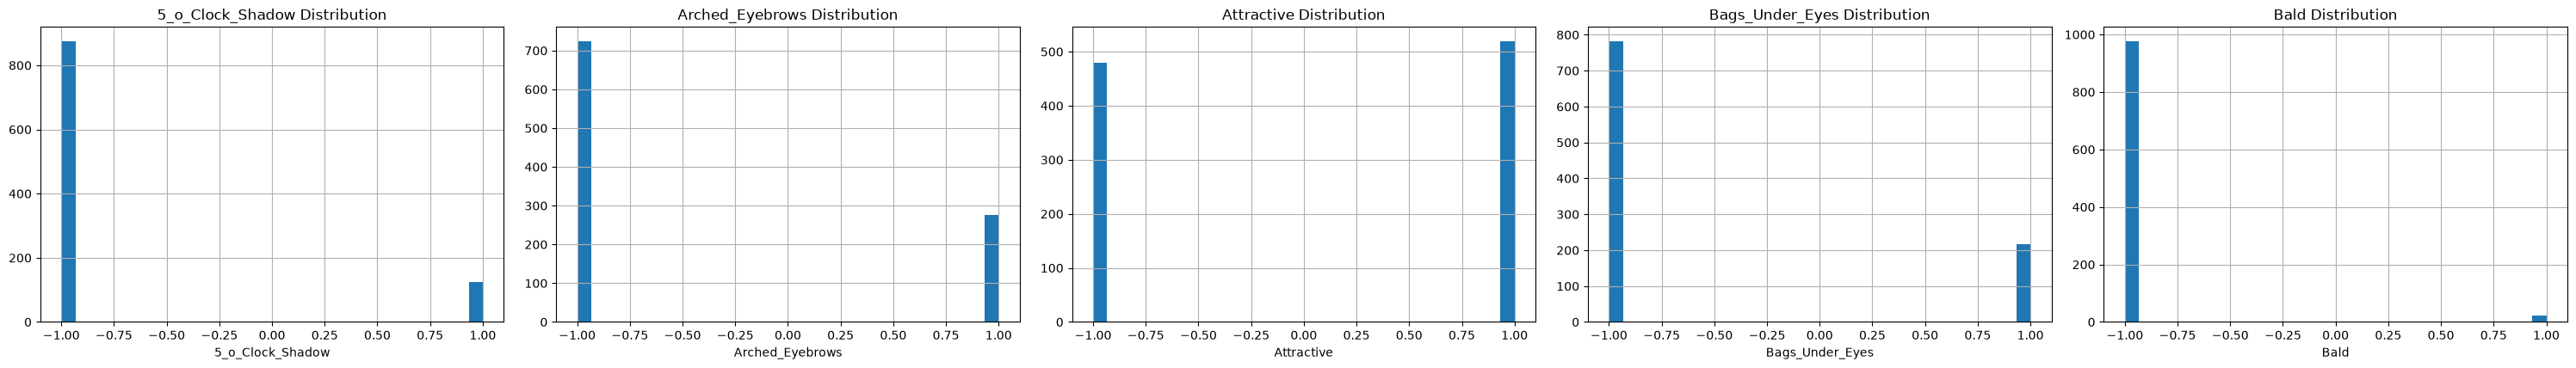

In [143]:
plotPerColumnDistribution(df1, 10, 5)


### Attribute Correlation Matrix
Examine pairwise correlations among numeric attribute columns to identify relationships.


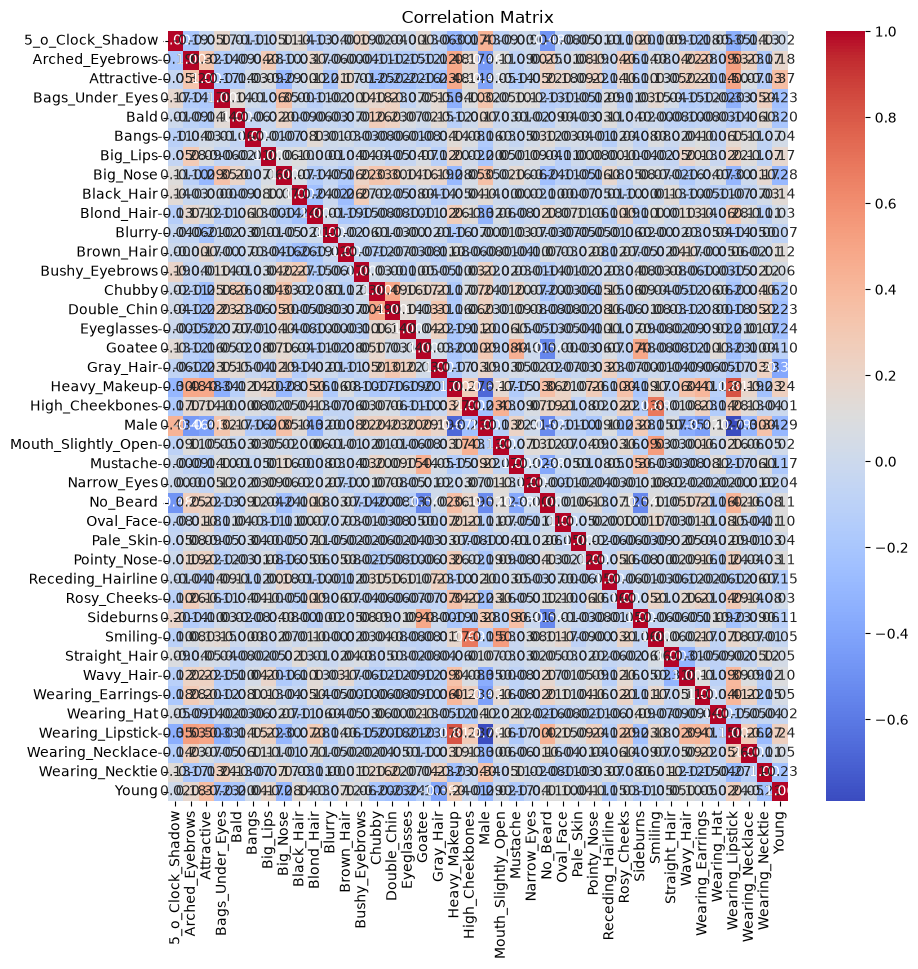

In [144]:
plotCorrelationMatrix(df1, 10)


### Attribute Scatter Matrix
Explore pairwise scatter relationships between numeric attributes for pattern detection.


<Figure size 2000x2000 with 0 Axes>

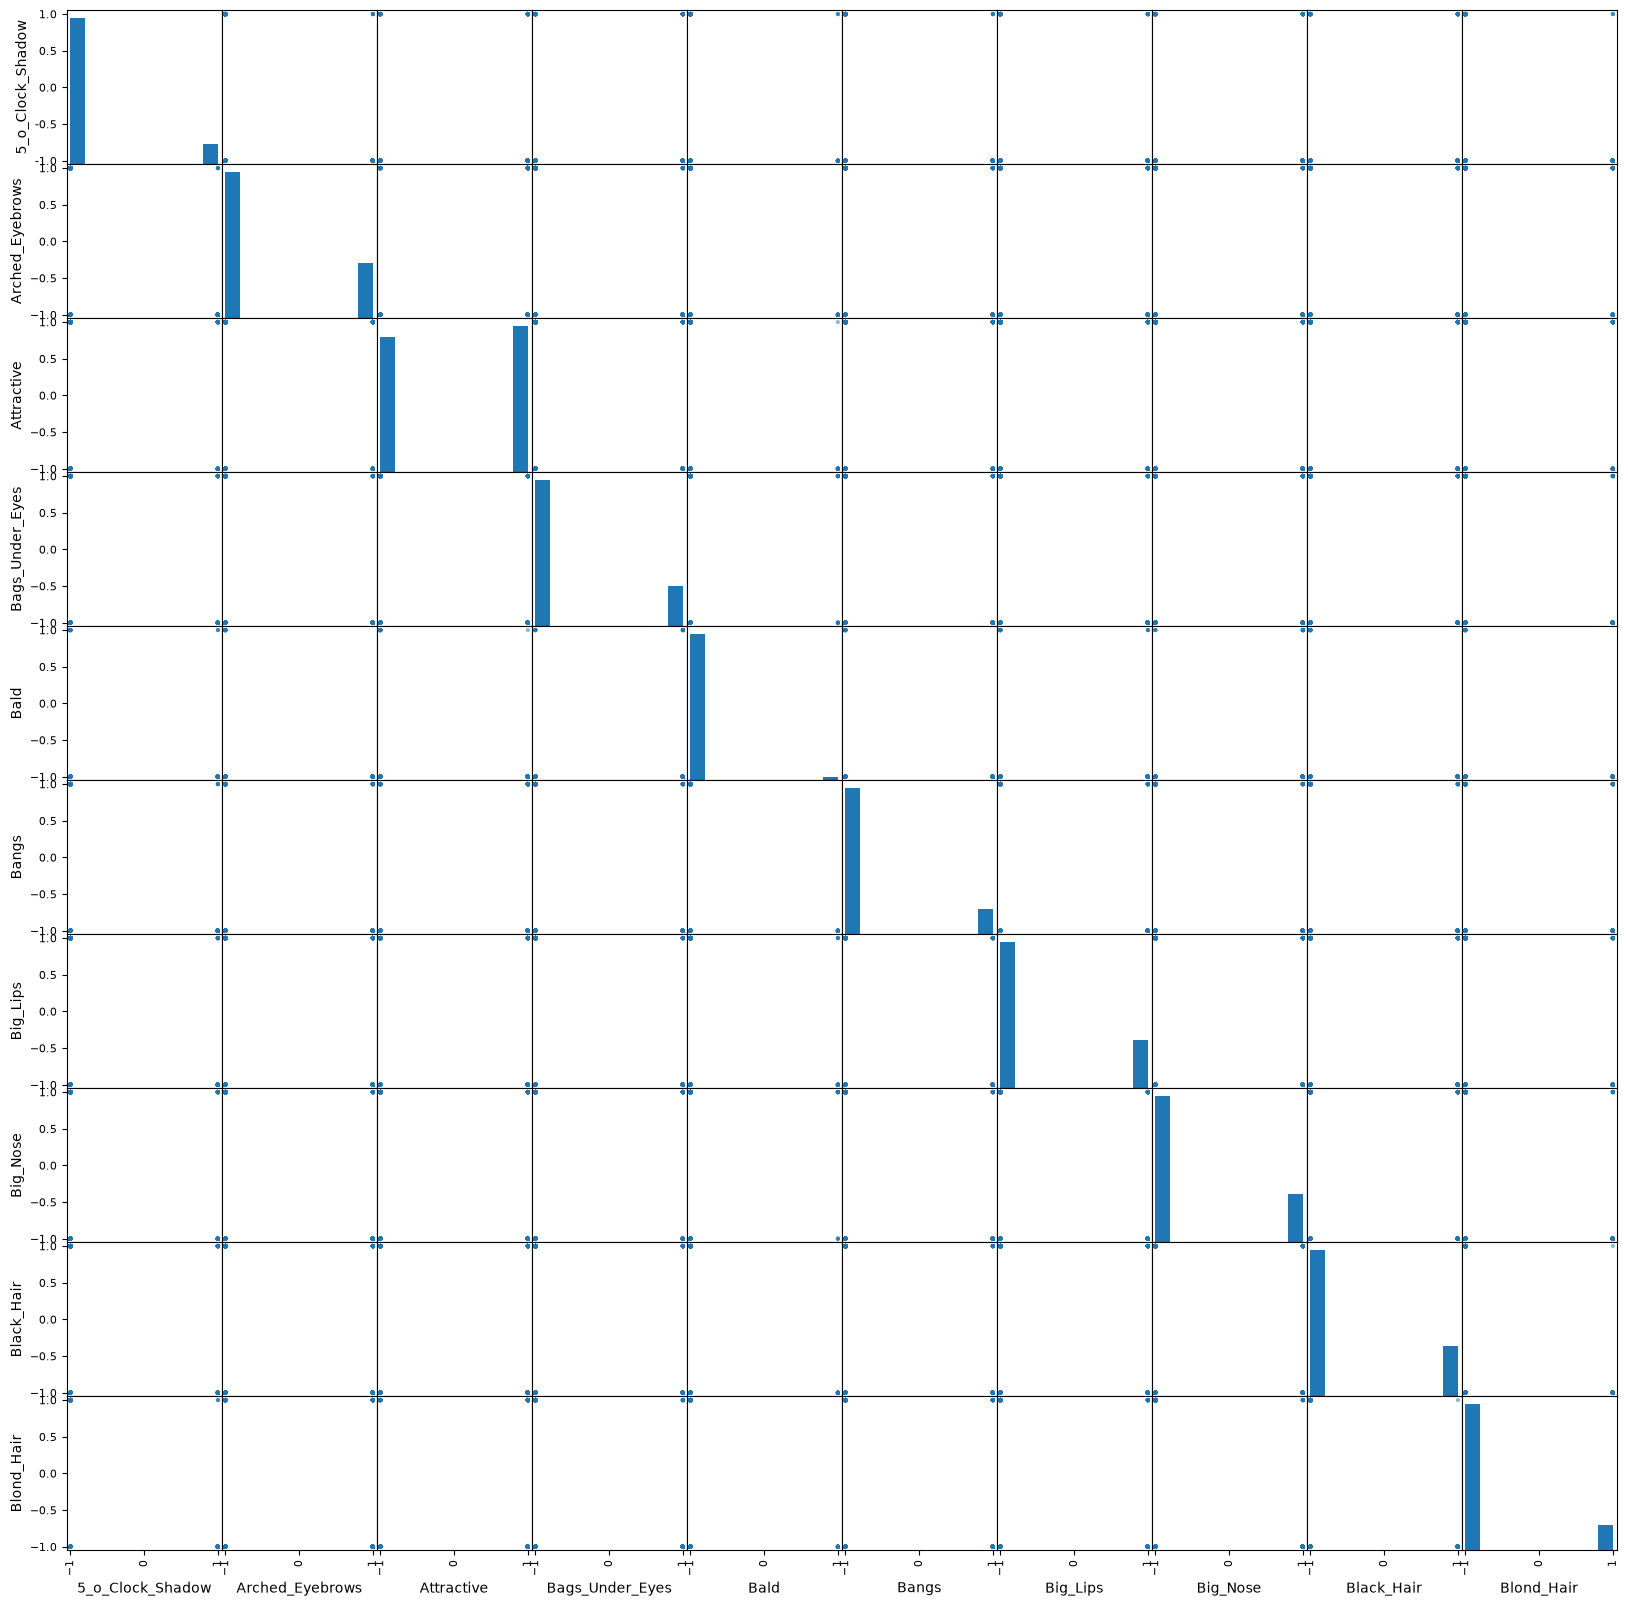

In [145]:
plotScatterMatrix(df1, 20, 10)

# Data Dictionary — `list_bbox_celeba.csv`

| Column | Type | Description |
|--------|------|-------------|
| `image_id` | string | Filename of the celebrity image |
| `x_1` | int | Leftmost x-coordinate of the face bounding box |
| `y_1` | int | Topmost y-coordinate of the face bounding box |
| `width` | int | Width of the bounding box |
| `height` | int | Height of the bounding box |
| `confidence` | float | Detection confidence score |
| `target` | int | Target class indicator |


# DataFrame 2 â€” Bounding Boxes (`list_bbox_celeba.csv`)
This dataset contains bounding box coordinates (`x`, `y`, `width`, `height`) for face regions in each image, along with `confidence` and `target`. We visualize the distributions and correlations.

### Loading Bounding Box Data
Read a sample of the CelebA bounding box annotations CSV to inspect its structure.


In [146]:
nRowsRead = 1000
df2 = pd.read_csv(os.path.join(DATA_DIR, 'list_bbox_celeba.csv'), delimiter=',', nrows=nRowsRead)
df2.dataframeName = 'list_bbox_celeba.csv'
nRow, nCol = df2.shape
print(f'There are {nRow} rows and {nCol} columns')
print('\n--- Schema ---')
print(df2.dtypes)
print('\n--- Missing Values ---')
print(df2.isnull().sum())
print('\n--- Unique Values Count ---')
print(df2.nunique())
print('\n--- Head ---')
display(df2.head(3))
print('\n--- Describe ---')
display(df2.describe(include='all'))


There are 1000 rows and 5 columns

--- Schema ---
image_id      str
x_1         int64
y_1         int64
width       int64
height      int64
dtype: object

--- Missing Values ---
image_id    0
x_1         0
y_1         0
width       0
height      0
dtype: int64

--- Unique Values Count ---
image_id    1000
x_1          352
y_1          209
width        189
height       203
dtype: int64

--- Head ---


,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126



--- Describe ---


,image_id,x_1,y_1,width,height
count,1000,1000.000000,1000.000000,1000.00000,1000.000000
unique,1000,NaN,NaN,NaN,NaN
top,000001.jpg,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,159.019000,85.286000,205.12100,283.421000
std,NaN,158.628407,81.071084,157.89533,217.977095
min,NaN,1.000000,1.000000,42.00000,58.000000
25%,NaN,72.000000,46.000000,122.00000,169.000000
50%,NaN,112.000000,67.500000,172.00000,238.000000
75%,NaN,186.250000,98.000000,234.00000,320.000000


### Preview of Bounding Box Data
Display the first five rows of the bounding box annotations.


In [147]:
df2.head(5)

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


### Bounding Box Distributions
Visualize the distributions of bounding box coordinates, dimensions, and confidence scores.


In [148]:
plotPerColumnDistribution(df2, 10, 5)

No valid columns to plot


### Bounding Box Correlation Matrix
Examine correlations between bounding box coordinates and confidence.


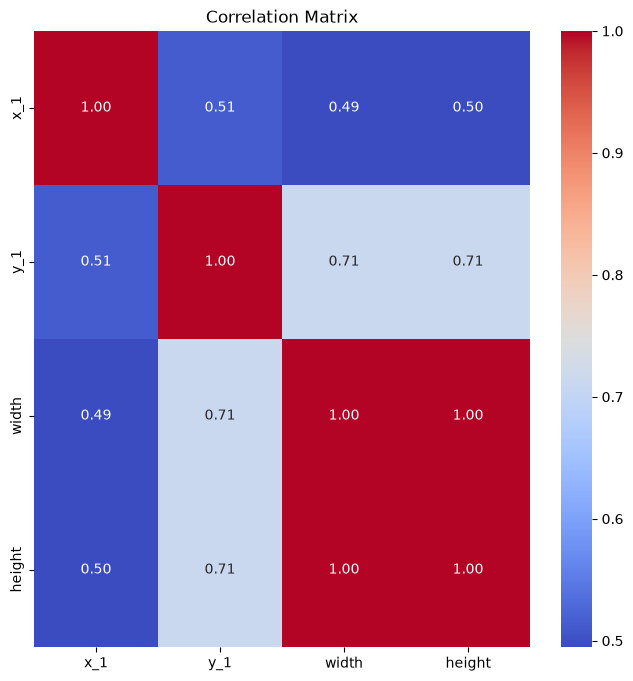

In [149]:
plotCorrelationMatrix(df2, 8)

### Bounding Box Scatter Matrix
Explore pairwise relationships among bounding box dimensions and confidence.


<Figure size 1200x1200 with 0 Axes>

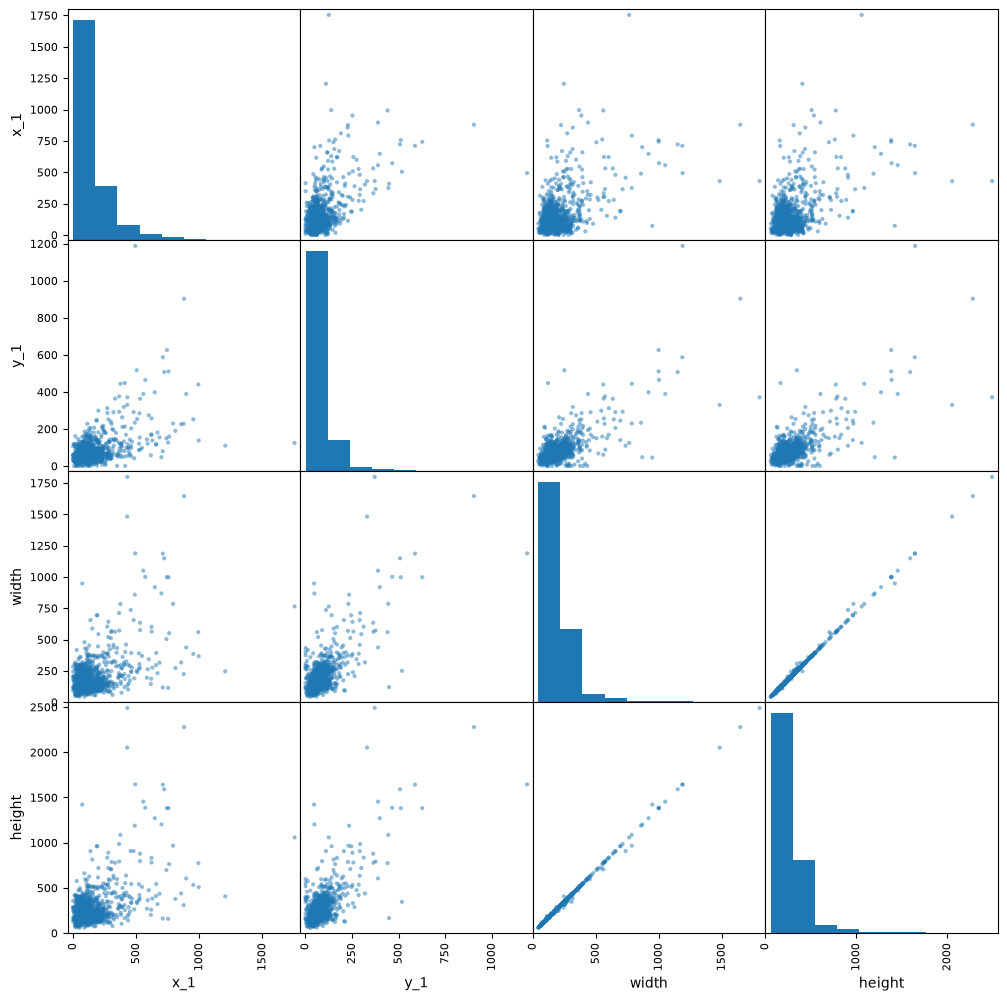

In [150]:
plotScatterMatrix(df2, 12, 10)

# Data Dictionary — `list_eval_partition.csv`

| Column | Type | Description |
|--------|------|-------------|
| `image_id` | string | Filename of the celebrity image |
| `partition` | int | Dataset split: 0 = Training, 1 = Validation, 2 = Test |


# DataFrame 3 â€” Evaluation Partition (`list_eval_partition.csv`)
This dataset assigns each image to a partition (`0` = Training, `1` = Validation, `2` = Test), enabling reproducibility of train/val/test splits.

### Loading Partition Data
Read the train/validation/test split assignments for each image.


In [151]:
nRowsRead = 1000
df3 = pd.read_csv(os.path.join(DATA_DIR, 'list_eval_partition.csv'), delimiter=',', nrows=nRowsRead)
df3.dataframeName = 'list_eval_partition.csv'
nRow, nCol = df3.shape
print(f'There are {nRow} rows and {nCol} columns')
print('\n--- Schema ---')
print(df3.dtypes)
print('\n--- Missing Values ---')
print(df3.isnull().sum())
print('\n--- Unique Values Count ---')
print(df3.nunique())
print('\n--- Head ---')
display(df3.head(3))
print('\n--- Describe ---')
display(df3.describe(include='all'))
print('\n--- Partition Value Counts ---')
print(df3['partition'].value_counts().sort_index())


There are 1000 rows and 2 columns

--- Schema ---
image_id       str
partition    int64
dtype: object

--- Missing Values ---
image_id     0
partition    0
dtype: int64

--- Unique Values Count ---
image_id     1000
partition       1
dtype: int64

--- Head ---


,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0



--- Describe ---


,image_id,partition
count,1000,1000.0
unique,1000,NaN
top,000001.jpg,NaN
freq,1,NaN
mean,NaN,0.0
std,NaN,0.0
min,NaN,0.0
25%,NaN,0.0
50%,NaN,0.0
75%,NaN,0.0



--- Partition Value Counts ---
partition
0    1000
Name: count, dtype: int64


### Preview of Partition Data
Display the first five rows of the evaluation partition assignments.


In [152]:
df3.head(5)

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


### Partition Distribution
Visualize the class distribution across training, validation, and test partitions.


In [153]:
plotPerColumnDistribution(df3, 10, 5)

No valid columns to plot


### Merging All Data Sources
Combine attributes, bounding boxes, landmarks, and partitions into a single consolidated dataset for multi-task training.


In [154]:
# Load full CSVs and merge into a single consolidated dataset
attrs = pd.read_csv(os.path.join(DATA_DIR, 'list_attr_celeba.csv'))
bbox = pd.read_csv(os.path.join(DATA_DIR, 'list_bbox_celeba.csv'))
landmarks = pd.read_csv(os.path.join(DATA_DIR, 'list_landmarks_align_celeba.csv'))
partition = pd.read_csv(os.path.join(DATA_DIR, 'list_eval_partition.csv'))

print('Pre-merge shapes:')
print('  attrs:', attrs.shape)
print('  bbox:', bbox.shape)
print('  landmarks:', landmarks.shape)
print('  partition:', partition.shape)

df = attrs.merge(bbox, on='image_id', how='inner') \
          .merge(landmarks, on='image_id', how='inner') \
          .merge(partition, on='image_id', how='inner')

print('\nPost-merge shape:', df.shape)
print('Missing image_id keys per merge step:')
print('  attrs vs bbox:', attrs['image_id'].isin(bbox['image_id']).sum(), '/', len(attrs))
print('  attrs vs landmarks:', attrs['image_id'].isin(landmarks['image_id']).sum(), '/', len(attrs))
print('  attrs vs partition:', attrs['image_id'].isin(partition['image_id']).sum(), '/', len(attrs))

# Persist merged dataset for downstream training
merged_path = os.path.join(DATA_DIR, 'celeba_merged.csv')
df.to_csv(merged_path, index=False)
print(f"\nSaved merged dataset to: {merged_path}")

attr_cols = [c for c in attrs.columns if c != 'image_id']
bbox_cols = ['x_1', 'y_1', 'width', 'height']
landmark_cols = [c for c in landmarks.columns if c != 'image_id']

# Validation checks
assert df['image_id'].is_unique, 'image_id is not unique in merged dataset'
assert df['image_id'].notnull().all(), 'Null image_id values found'
print('\nValidation passed: no null image_id, shape =', df.shape)


Pre-merge shapes:
  attrs: (202599, 41)
  bbox: (202599, 5)
  landmarks: (202599, 11)
  partition: (202599, 2)

Post-merge shape: (202599, 56)
Missing image_id keys per merge step:
  attrs vs bbox: 202599 / 202599
  attrs vs landmarks: 202599 / 202599
  attrs vs partition: 202599 / 202599

Saved merged dataset to: d:\CODING\project\TODO Projects\FaceInsight-AI\archive\celeba_merged.csv

Validation passed: no null image_id, shape = (202599, 56)


### Image Loading and Dataset Pipeline
Define TensorFlow utilities to read, decode, resize, and batch images with their corresponding labels.


In [155]:
IMG_SIZE = 512  # start small, bump to 224 later if it helps

def load_img(path, label):
    """
    Read, decode, resize, and normalize a JPEG image.

    Args:
        path (str): File path to the JPEG image.
        label: Target label (passed through unchanged).

    Returns:
        tuple: (normalized image tensor, label).
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

def make_ds(df, label_col, shuffle=False):
    """
    Build a tf.data.Dataset from a DataFrame of image paths and binary labels.

    Args:
        df (pd.DataFrame): DataFrame containing `image_id` and the target column.
        label_col (str): Column name whose values are treated as binary labels.
        shuffle (bool): Whether to shuffle the dataset.

    Returns:
        tf.data.Dataset: Batched and prefetched dataset.
    """
    paths = (img_dir + df.image_id).values
    labels = (df[label_col] == 1).astype(int).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000)
    return ds.batch(64).prefetch(tf.data.AUTOTUNE)


### TensorFlow and Model Imports
Import TensorFlow/Keras modules needed to build and train the multi-task model.


In [156]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


### Loading Merged Dataset for Training
Load the consolidated dataset and verify its shape, column definitions, and target attributes.


In [157]:
# Load pre-merged dataset (generated in the merge cell above)
merged_path = os.path.join(DATA_DIR, 'celeba_merged.csv')
df = pd.read_csv(merged_path)

landmarks = pd.read_csv(os.path.join(DATA_DIR, 'list_landmarks_align_celeba.csv'))

attr_cols = [c for c in df.columns if c not in ('image_id', 'x_1', 'y_1', 'width', 'height', 'confidence', 'target', 'partition')]
bbox_cols = ['x_1', 'y_1', 'width', 'height']
landmark_cols = [c for c in landmarks.columns if c != 'image_id']

print('Loaded merged dataset shape:', df.shape)
print('Attribute columns:', len(attr_cols))
print('BBox columns:', bbox_cols)
print('Landmark columns:', len(landmark_cols))
df.head()


Loaded merged dataset shape: (202599, 56)
Attribute columns: 50
BBox columns: ['x_1', 'y_1', 'width', 'height']
Landmark columns: 10


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y,partition
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,109,106,113,77,142,73,152,108,154,0
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,110,107,112,81,135,70,151,108,153,0
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,112,104,106,108,128,74,156,98,158,0
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,113,108,108,101,138,71,155,101,151,0
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,114,112,112,86,119,71,147,104,150,0


### Visualizing Sample Images
Display sample images with overlaid bounding boxes and facial landmarks to verify annotation quality.


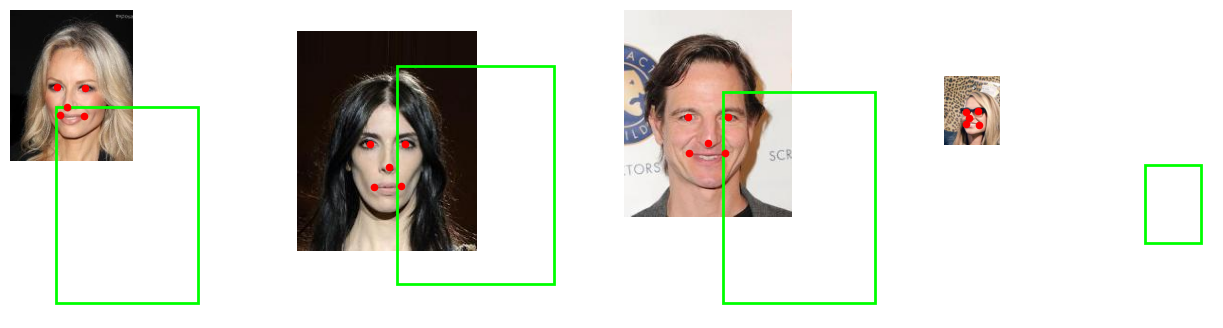

In [158]:
img_dir = os.path.join(DATA_DIR, 'img_align_celeba', 'img_align_celeba') + os.sep

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, df.sample(4, random_state=1).iterrows()):
    img = plt.imread(img_dir + row['image_id'])
    ax.imshow(img)
    ax.add_patch(plt.Rectangle((row.x_1, row.y_1), row.width, row.height,
                                edgecolor='lime', facecolor='none', linewidth=2))
    xs = [row[c] for c in landmark_cols if c.endswith('_x')]
    ys = [row[c] for c in landmark_cols if c.endswith('_y')]
    ax.scatter(xs, ys, c='red', s=20)
    ax.axis('off')
plt.show()

### Train/Validation/Test Split and Normalization
Split the data by partition and normalize bounding-box and landmark coordinates to the [0, 1] range.


In [159]:
IMG_SIZE = 128

train_df = df[df.partition == 0].reset_index(drop=True)
val_df   = df[df.partition == 1].reset_index(drop=True)
test_df  = df[df.partition == 2].reset_index(drop=True)

def normalize_targets(d):
    """
    Normalize bounding-box and landmark coordinates to [0, 1].

    Args:
        d (pd.DataFrame): DataFrame containing bbox and landmark columns.

    Returns:
        pd.DataFrame: Copy with normalized coordinates.
    """
    d = d.copy()
    d[bbox_cols[0]] = d[bbox_cols[0]] / 178.0   # x_1 / img width
    d[bbox_cols[2]] = d[bbox_cols[2]] / 178.0   # width
    d[bbox_cols[1]] = d[bbox_cols[1]] / 218.0   # y_1 / img height
    d[bbox_cols[3]] = d[bbox_cols[3]] / 218.0   # height
    for c in landmark_cols:
        d[c] = d[c] / (178.0 if c.endswith('_x') else 218.0)
    return d

train_df, val_df, test_df = normalize_targets(train_df), normalize_targets(val_df), normalize_targets(test_df)
print(len(train_df), len(val_df), len(test_df))


162770 19867 19962


### Multi-Task Dataset Pipeline
Create a tf.data.Dataset pipeline that loads images and prepares targets for attributes, landmarks, and bounding boxes simultaneously.


In [160]:
def load_and_preprocess(path, attr, land, box):
    """
    Read, decode, resize, and normalize an image for multi-task training.

    Args:
        path (str): Image file path.
        attr (np.ndarray): Binary attribute vector.
        land (np.ndarray): Landmark coordinate vector.
        box (np.ndarray): Bounding box vector.

    Returns:
        tuple: (normalized image tensor, dict of task targets).
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, {'attributes': attr, 'landmarks': land, 'bbox': box}

def make_dataset(d, shuffle=False, batch_size=64):
    """
    Create a tf.data.Dataset for multi-task face analysis.

    Args:
        d (pd.DataFrame): Merged DataFrame with image paths and targets.
        shuffle (bool): Whether to shuffle the dataset.
        batch_size (int): Batch size.

    Returns:
        tf.data.Dataset: Batched and prefetched dataset.
    """
    paths = (img_dir + d['image_id']).values
    attr = ((d[attr_cols].values == 1).astype('float32'))
    land = d[landmark_cols].values.astype('float32')
    box = d[bbox_cols].values.astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((paths, attr, land, box))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


### Multi-Task Model Architecture
Build a Keras model with a frozen MobileNetV2 backbone and three task-specific heads: attributes, landmarks, and bounding boxes.


In [161]:
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

backbone = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
backbone.trainable = False

x = backbone(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

attributes_out = Dense(len(attr_cols), activation='sigmoid', name='attributes')(x)
landmarks_out = Dense(len(landmark_cols), activation='sigmoid', name='landmarks')(x)
bbox_out = Dense(len(bbox_cols), activation='sigmoid', name='bbox')(x)

model = Model(inputs=inputs, outputs=[attributes_out, landmarks_out, bbox_out])
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_10[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attributes (Dense)  │ (None, 50)        │     12,850 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ landmarks (Dense)   │ (None, 10)        │      2,570 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox (Dense)        │ (None, 4)         │      1,028 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,602,368 (9.93 MB)

 Trainable params: 344,384 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Model Compilation
Configure the optimizer, per-task loss functions, loss weights, and evaluation metrics.


In [162]:
model.compile(
    optimizer='adam',
    loss={
        'attributes': 'binary_crossentropy',
        'landmarks': 'mse',
        'bbox': 'mse'
    },
    loss_weights={
        'attributes': 1.0,
        'landmarks': 5.0,
      'bbox': 5.0
    },
    metrics={
        'attributes': 'accuracy',
        'landmarks': 'mae',
        'bbox': 'mae'
    }
)

### Chunked Training Execution
Define a chunked training loop that processes the dataset in manageable batches, saving checkpoints after each chunk.


In [163]:
CHUNK_SIZE = 40000
EPOCHS_PER_CHUNK = 2
CHECKPOINT_DIR = os.path.join(DATA_DIR, 'training_checkpoints')

def train_chunked(model, train_df, val_ds, epochs_per_chunk=EPOCHS_PER_CHUNK,
                   chunk_size=CHUNK_SIZE, checkpoint_dir=CHECKPOINT_DIR,
                   callbacks=None):
    import gc
    if callbacks is None:
        callbacks = []
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoints = sorted([f for f in os.listdir(checkpoint_dir)
                          if f.startswith('chunk_') and f.endswith('.keras')])
    start_chunk = 0

    if checkpoints:
        last_ckpt_name = checkpoints[-1]
        last_chunk = int(last_ckpt_name.split('_')[1].split('.')[0])
        ckpt_path = os.path.join(checkpoint_dir, last_ckpt_name)
        print(f"Resuming from chunk {last_chunk}")
        model = tf.keras.models.load_model(ckpt_path)
        start_chunk = last_chunk

    num_chunks = int(np.ceil(len(train_df) / chunk_size))
    print(f"Total chunks: {num_chunks}")

    for chunk_idx in range(start_chunk, num_chunks):
        start = chunk_idx * chunk_size
        end = min(start + chunk_size, len(train_df))
        chunk_df = train_df.iloc[start:end].reset_index(drop=True)

        chunk_train_ds = make_dataset(chunk_df, shuffle=True)

        history = model.fit(
            chunk_train_ds,
            validation_data=val_ds,
            epochs=epochs_per_chunk,
            callbacks=callbacks,
            verbose=1
        )

        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        print(f"Chunk {chunk_idx + 1}/{num_chunks} — Train loss: {final_train_loss:.4f}, Val loss: {final_val_loss:.4f}")

        ckpt_path = os.path.join(checkpoint_dir, f'chunk_{chunk_idx + 1}.keras')
        model.save(ckpt_path)

        del chunk_train_ds, chunk_df
        gc.collect()

    return model

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
train_ds = make_dataset(train_df, shuffle=True)

model = train_chunked(
    model,
    train_df,
    val_ds,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 1607s 626ms/step - attributes_accuracy: 0.0138 - attributes_loss: 0.2737 - bbox_loss: 0.5874 - bbox_mae: 0.3856 - landmarks_loss: 0.0018 - landmarks_mae: 0.0232 - loss: 3.2202 - val_attributes_accuracy: 0.0136 - val_attributes_loss: 0.2428 - val_bbox_loss: 0.5969 - val_bbox_mae: 0.3779 - val_landmarks_loss: 2.4847e-04 - val_landmarks_mae: 0.0098 - val_loss: 3.2291 - learning_rate: 0.0010
Epoch 2/15
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 1579s 618ms/step - attributes_accuracy: 0.0144 - attributes_loss: 0.2533 - bbox_loss: 0.5808 - bbox_mae: 0.3768 - landmarks_loss: 2.7110e-04 - landmarks_mae: 0.0103 - loss: 3.1591 - val_attributes_accuracy: 0.0144 - val_attributes_loss: 0.2366 - val_bbox_loss: 0.5963 - val_bbox_mae: 0.3809 - val_landmarks_loss: 2.4495e-04 - val_landmarks_mae: 0.0099 - val_loss: 3.2197 - learning_rate: 0.0010
Epoch 3/15
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 2317s 908ms/step - attributes_accuracy: 0.0146 - attributes_loss: 0.2495 - bbox_loss: 0.

### Fine-Tuning the Backbone
Unfreeze the MobileNetV2 backbone and continue training with a lower learning rate to refine feature extraction.


In [ ]:
backbone.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={'attributes': 'binary_crossentropy', 'landmarks': 'mse', 'bbox': 'mse'},
    loss_weights={'attributes': 1.0, 'landmarks': 5.0, 'bbox': 5.0},
    metrics={'attributes': 'accuracy', 'landmarks': 'mae', 'bbox': 'mae'}
)

model = train_chunked(
    model,
    train_df,
    val_ds,
    checkpoint_dir=os.path.join(DATA_DIR, 'training_checkpoints_ft'),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 5808s 2s/step - attributes_accuracy: 0.0145 - attributes_loss: 0.3012 - bbox_loss: 0.5814 - bbox_mae: 0.3789 - landmarks_loss: 2.7116e-04 - landmarks_mae: 0.0102 - loss: 3.2087 - val_attributes_accuracy: 0.0132 - val_attributes_loss: 0.2484 - val_bbox_loss: 0.5977 - val_bbox_mae: 0.3617 - val_landmarks_loss: 2.3073e-04 - val_landmarks_mae: 0.0093 - val_loss: 3.2385 - learning_rate: 1.0000e-05
Epoch 2/15
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 5870s 2s/step - attributes_accuracy: 0.0149 - attributes_loss: 0.2567 - bbox_loss: 0.5630 - bbox_mae: 0.3516 - landmarks_loss: 2.4008e-04 - landmarks_mae: 0.0095 - loss: 3.0732 - val_attributes_accuracy: 0.0143 - val_attributes_loss: 0.2322 - val_bbox_loss: 0.5770 - val_bbox_mae: 0.3481 - val_landmarks_loss: 2.1349e-04 - val_landmarks_mae: 0.0089 - val_loss: 3.1189 - learning_rate: 1.0000e-05
Epoch 3/15
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 9406s 4s/step - attributes_accuracy: 0.0160 - attributes_loss: 0.2445 - bbox_loss:

### Evaluation Metrics
Evaluate the final model on the test set using macro-F1, mean Average Precision for attributes, and MAE for landmarks and bounding boxes.


In [ ]:
from sklearn.metrics import f1_score, average_precision_score

results = model.evaluate(test_ds, return_dict=True)
print(results)

# per-attribute F1 / mAP
attr_pred, land_pred, box_pred = model.predict(test_ds)
attr_true = (test_df[attr_cols].values == 1).astype(int)
attr_pred_labels = (attr_pred > 0.5).astype(int)

macro_f1 = f1_score(attr_true, attr_pred_labels, average='macro')
mAP = average_precision_score(attr_true, attr_pred, average='macro')
print(f"Attributes macro-F1: {macro_f1:.4f}")
print(f"Attributes mAP:      {mAP:.4f}")

land_true = test_df[landmark_cols].values
landmark_mae = np.abs(land_pred - land_true).mean()
print(f"Landmark MAE (normalized): {landmark_mae:.4f}")

box_true = test_df[bbox_cols].values
bbox_mae = np.abs(box_pred - box_true).mean()
print(f"Bbox MAE (normalized): {bbox_mae:.4f}")

### Saving the Final Model
Persist the trained multi-task model to disk for future inference or deployment.


In [ ]:
model.save("multitask_face_model.keras")